In [1]:
import numpy as np
import pickle
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from model.neural_net import PhysicsInformedNN

2024-11-21 12:19:16.114464: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1732187956.132001   17911 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1732187956.137211   17911 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-21 12:19:16.153860: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Load log and weights file

In [2]:
run_path = Path('logs')

log_path = run_path.rglob('*.json')
for log_file in log_path:
    with open(log_file, 'r') as f:
        log = json.load(f)

epoch_weights = np.arange(0, 50000, 1000)
weights = {}
for epoch in epoch_weights:
    weights_file = run_path.joinpath(f'model_weights/weights_{epoch}.pkl')
    with open(weights_file, 'rb') as pickle_file:
        weights[epoch] = pickle.load(pickle_file)

### Auxiliary Functions to process weights files and vectors

In [3]:
# extract structure information from an example weight file
# used in flatt2vec function
size_list, shape_list = [], []
size = 0
for v in weights[0]:
    shape = v.shape
    size += np.prod(shape)
    size_list.append(size)
    shape_list.append(shape)
size_list = size_list[:-1]

# used to convert tensorflow weight structure to flatten vector
def vec2flatt(vec):
    return np.concatenate([np.reshape(v, -1) for v in vec])

# used to reconstruct flatten weight vector to original structure
def flatt2vec(vec_flatt):
    vec = np.split(vec_flatt, size_list)
    vec_rec = []
    for v, shape in zip(vec, shape_list):
        vec_rec.append(v.reshape(shape))
    return vec_rec

# pairwise iterator
def pairwise(t):
    it = iter(t)
    return zip(it,it)

### 

### Determine (orthogonalized) weight vector directions

In [4]:
#######################
### Vector Settings
#######################
ep0, ep1, ep2 = 0, 20000, 49000
w0, w1, w2 = weights[ep0], weights[ep1], weights[ep2]
w0_flatt = vec2flatt(w0)
w1_flatt = vec2flatt(w1)
w2_flatt = vec2flatt(w2)

vec10_flatt = w1_flatt - w0_flatt
vec20_flatt = w2_flatt - w0_flatt

# orthogonalization
vec20_flatt -= (np.dot(vec10_flatt, vec20_flatt) / np.dot(vec10_flatt, vec10_flatt)) * vec10_flatt
vec10 = flatt2vec(vec10_flatt)
vec20 = flatt2vec(vec20_flatt)

####################
### PINN initialization
####################
pinn = PhysicsInformedNN(log, verbose=False)
pinn.neural_net.set_weights(w0)

*** PINN build & initialized ***


/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2024-11-21 12:19:18.149023: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2024-11-21 12:19:18.149084: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: mbabic-ubuntu
2024-11-21 12:19:18.149102: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: mbabic-ubuntu
2024-11-21 12:19:18.149244: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 550.120.0
2024-11-21 12:19:18.149298: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 550.120.0
2024-11-21 12:19:18.149323: I external/lo

### Plotting functions

In [5]:
# determines alpha and beta
grid_range = np.arange(-0.6, 1.51, 0.05)

def loss_landscape_2d(model, vec1, vec2, t_col, reg="no_reg"):
  
    N_grid = len(grid_range)
    
    # initial network weights
    model_weights = w0
    
    # set regularization
    model.loss.regularizer = model.loss.regularization_map[reg]

    # get current loss
    physics_loss0 = model.loss.toy_example(t_col, reg_coeff=1)
    
    # prepare 2d array for loss landscape
    loss_2d = {'F': np.zeros([N_grid, N_grid])}    
    
    # construct loss landscape
    for i, alpha in enumerate(grid_range):
        for j, beta in enumerate(grid_range):
            
            # apply random direction vectors
            weights_new = [w+alpha*v1+beta*v2 for w,v1,v2 in zip(model_weights, vec1, vec2)]
            model.neural_net.set_weights(weights_new)
            
            # physics loss
            physics_loss =  model.loss.toy_example(t_col, reg_coeff=1)

            loss_2d['F'][i,j] = physics_loss
               
    for key, item in loss_2d.items():
        loss_2d[key] = item.tolist()
    loss_2d.update({'loss_F0': physics_loss0,
                    'grid_range': grid_range.tolist()})
    
    # restore original weights
    model.neural_net.set_weights(model_weights)
    return loss_2d


def get_loss_landscape(T=8, trunc_F=0.2, reg="no_reg"):
    
    n_col = 1024
    t_col = np.linspace(0, T, n_col)
    t_col = np.expand_dims(t_col, axis=1)
    t_col = tf.convert_to_tensor(t_col, dtype=tf.float32)
    
    loss_landscape = loss_landscape_2d(pinn, vec10, vec20, t_col, reg=reg)
    
    loss_F = np.array(loss_landscape['F'])
    loss_F = np.where(loss_F>trunc_F, trunc_F, loss_F)
    
    return loss_F


#######################
### Trajectory Settings
#######################
def trajectory_projection(epochs_traj):
    traj_10, traj_20 = [],[]
    
    for epoch in epochs_traj:
    
        w = weights[epoch]

        w_flatt = vec2flatt(w) - w0_flatt

        k_10 = np.dot(w_flatt, vec10_flatt) / np.dot(vec10_flatt, vec10_flatt)
        k_20 = np.dot(w_flatt, vec20_flatt) / np.dot(vec20_flatt, vec20_flatt)

        traj_10.append(k_10)
        traj_20.append(k_20)
        
    return traj_10, traj_20

# Trajectory Plot

/tmp/ipykernel_17911/422099376.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('jet_r')


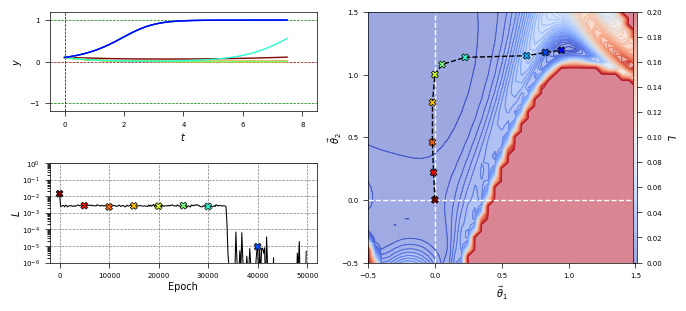

/tmp/ipykernel_17911/422099376.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('jet_r')


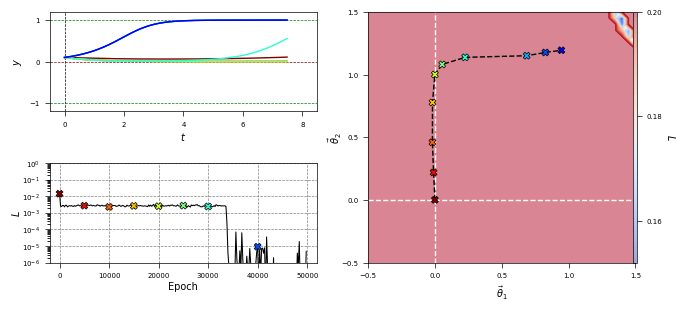

/tmp/ipykernel_17911/422099376.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('jet_r')


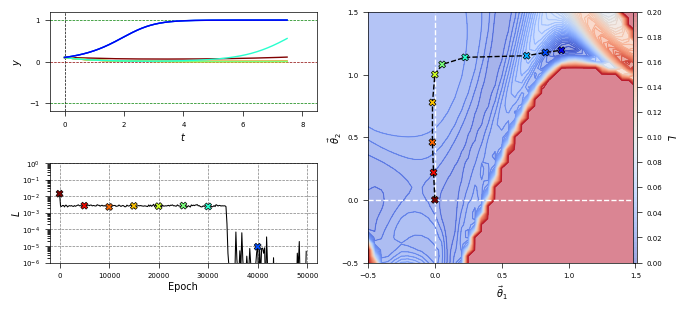

/tmp/ipykernel_17911/422099376.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('jet_r')


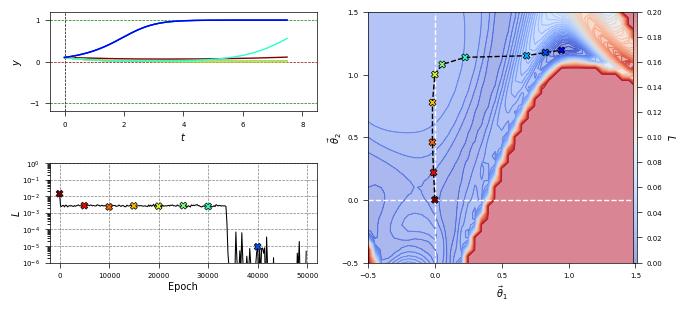

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

for reg in ["no_reg", "reg_derivative", "unstable_fp", "reg_derivative_unstable_fp"]:

    #########################
    ### Figure and Axis Grid
    #########################
    plt.rcParams.update({'font.size': 5,
                        'axes.labelsize': 7,
                        'axes.linewidth': .5,
                        'xtick.major.width': .5,
                        'ytick.major.width': .5})


    layout = ['singleCol', 'doubleCol'][1]

    ### single column layout (ICML)
    if layout == 'singleCol':
        fig = plt.figure(constrained_layout=True, figsize=(3.25,5.)) #(3.25,5.25)
        fig.set_constrained_layout_pads(hspace=-0.02, wspace=0.)
        gs = GridSpec(3, 1, figure=fig, height_ratios=[.75,.75,1.5]) #[.75,.75,1.25]
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        ax3 = fig.add_subplot(gs[2])
    ### double column layout (arXiv)
    elif layout == 'doubleCol':
        fig = plt.figure(constrained_layout=True, figsize=(6.75,3.))
        fig.set_constrained_layout_pads(hspace=-0.02, wspace=0.02)
        gs = GridSpec(2, 2, figure=fig, height_ratios=[1.,1.])
        ax1 = fig.add_subplot(gs[0,0])
        ax2 = fig.add_subplot(gs[1,0])
        ax3 = fig.add_subplot(gs[:,1])

    ####
    ## aux func for color
    ####
    cmap = mpl.cm.get_cmap('jet_r')
    color_traj = lambda epoch: cmap(epoch/log['N_epochs'])

    ####
    ## aux dict for loss_F
    ####
    n_epochs, freq_log = log['N_epochs'], log['freq_log']
    epochs = np.arange(0 ,n_epochs, freq_log)
    loss_F = log['loss']
    loss_dict = dict(zip(epochs, loss_F))

    #########################
    ### Plot Trajectory
    #########################

    ####
    ## stable & instable solutions
    ####
    props = {'lw': 0.5, 'ls': '--', 'zorder': 0}
    ax1.axvline(0, c='black', **props)
    ax1.axhline(0, c='darkred', **props)
    ax1.axhline(1, c='green', **props)
    ax1.axhline(-1, c='green', **props)

    #########################
    ### Plot Trajectory
    #########################
    epochs_traj = np.arange(0, 50000, 5000)
    t_line = pinn.data.t_line()
    for epoch in epochs_traj:
        pinn.neural_net.set_weights(weights[epoch])
        
        y_pred = pinn(t_line)
        
        ax1.plot(t_line, y_pred, c=color_traj(epoch), 
                lw=1.0, alpha=1.0, zorder=10)
        
        pinn.neural_net.set_weights(w0)

    ####
    ## axis appearance
    ####
    ax1.set_xlim([-0.5, 8.5])
    ax1.set_xticks(np.arange(0, 8.1, 2))
    ax1.set_xlabel(r'$t$', labelpad=2)

    ax1.set_ylim([-1.2, 1.2])
    ax1.set_yticks([-1, 0, 1])
    ax1.set_ylabel(r'$y$')


    #########################
    ### Learning Curves
    #########################
    epochs_lc = np.arange(0, 50000, 200)
    loss_lc = [loss_dict[epoch] for epoch in epochs_lc]
    loss_traj = [loss_dict[epoch] for epoch in epochs_traj]

    ax2.plot(epochs_lc, loss_lc, c='black', lw=0.75, ls='-')
    ax2.scatter(epochs_traj, loss_traj, 
                c=color_traj(epochs_traj),
                s=25, marker='X', lw=0.5, edgecolor='black', zorder=10)


    ####
    ## axis appearance
    ####
    ax2.set_yscale('log')
    ax2.set_ylim([1e-6, 1e+00])
    #ax2.set_yticks(np.logspace(-10, 0, 6))
    ax2.set_ylabel(r'$L$', labelpad=0)
        
    ax2.set_xlim([-2000, 52000])
    #ax2.set_xticks([0, 25000, 50000])
    ax2.set_xlabel('Epoch', labelpad=2)

    ax2.grid(ls='--', lw=0.5, c='0.5')


    #########################
    ### Loss Landscape
    #########################

    ####
    ## Loss Contour
    ####
    props = {'levels': 50, 'cmap':'coolwarm'}
    ll_F = get_loss_landscape(T=8, trunc_F=0.2, reg=reg)
    X, Y = np.meshgrid(grid_range, grid_range)

    contf = ax3.contourf(X, Y, ll_F, **props, alpha=.5)
    ax3.contour(X, Y, ll_F, **props, linewidths=.75)
    if layout == 'singleCol': 
        aspect = 20
        pad = -0.04
    elif layout == 'doubleCol': 
        aspect = 60
        pad = -0.03
    cbar = fig.colorbar(contf, ax=ax3, format='%.2f', ticks=np.arange(0, 0.201, 0.02),
                        pad=pad, aspect=aspect)
    cbar.set_label(r'$L$', rotation=270, labelpad=10)

    ax3.axhline(0, ls='--', c='white', lw=1, alpha=1.)
    ax3.axvline(0, ls='--', c='white', lw=1, alpha=1.)

    ####
    ## Loss trajectory
    ####
    traj_10, traj_20 = trajectory_projection(epochs_traj)
    ax3.plot(traj_20, traj_10, ls='--', c='black', lw=1., alpha=1.)
    ax3.scatter(traj_20, traj_10, c=color_traj(epochs_traj), 
                s=25, marker='X', lw=0.5, edgecolor='black', zorder=10)


    ####
    ## axis appearance
    ####
    ax3.set_xlim([-0.5, 1.5])
    ax3.set_ylim([-0.5, 1.5])
    ax3.set_xticks(np.arange(-0.5, 1.51, 0.5))
    ax3.set_yticks(np.arange(-0.5, 1.51, 0.5))

    ax3.set_xlabel(r'$\vec\theta_{1}$')
    ax3.set_ylabel(r'$\vec\theta_{2}$', labelpad=-2)

    plt.savefig(f'loss_landscape_trajectory_{reg}.pdf')
    plt.show()

# Reduced Time Model

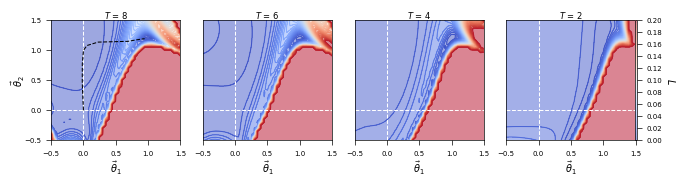

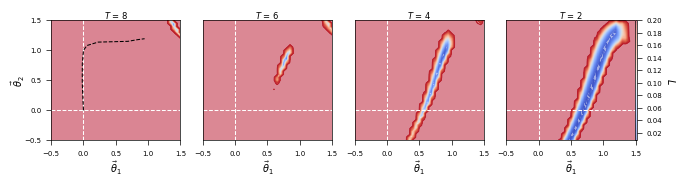

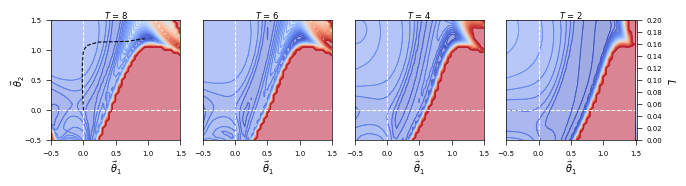

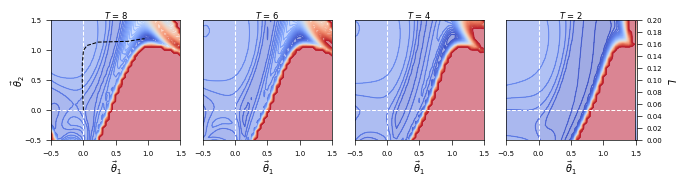

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

for reg in ["no_reg", "reg_derivative", "unstable_fp", "reg_derivative_unstable_fp"]:
    #########################
    ### Figure and Axis Grid
    #########################
    plt.rcParams.update({'font.size': 5,
                        'axes.labelsize': 7,
                        'axes.linewidth': .5,
                        'xtick.major.width': .5,
                        'ytick.major.width': .5})

    layout = ['doubleCol', 'singleRow'][1]

    ### double column layout (ICML)
    if layout == 'doubleCol':
        fig, axes = plt.subplots(2,2, figsize=(3.25, 2.5), constrained_layout=True)
        fig.set_constrained_layout_pads(hspace=-0.02, wspace=-0.02)
    ### single row layout (arXiv)
    if layout == 'singleRow':
        fig, axes = plt.subplots(1,4, figsize=(6.75, 1.75), constrained_layout=True)
        fig.set_constrained_layout_pads(hspace=-0.02, wspace=-0.02)
        
    ####
    ## Loss Contour
    ####
    X, Y = np.meshgrid(grid_range, grid_range)
    props = {'levels': 50, 'cmap':'coolwarm'}

    T_list = [8, 6, 4, 2]
    for T, ax in zip(T_list, axes.flatten()):
        ax.set_title(rf'$T$ = {T}', pad=0)
        
        ll_F = get_loss_landscape(T=T, trunc_F=0.2, reg=reg)

        contf = ax.contourf(X, Y, ll_F, **props, alpha=.5)
        ax.contour(X, Y, ll_F, **props, linewidths=.75)

        ax.axhline(0, ls='--', c='white', lw=.75, alpha=1.)
        ax.axvline(0, ls='--', c='white', lw=.75, alpha=1.)
        
    ####
    ## Loss trajectory
    ####
    epochs_traj = np.arange(0, 50000, 5000)
    traj_10, traj_20 = trajectory_projection(epochs_traj)
    axes.flatten()[0].plot(traj_20, traj_10, ls='--', c='black', lw=.75, alpha=1.)

    ####
    ## Colorbar
    ####    
    if layout == 'doubleCol': 
        aspect = 40
        pad = -0.02
    elif layout == 'singleRow': 
        aspect = 60
        pad = -0.01
    cbar = fig.colorbar(contf, ax=axes, format='%.2f', 
                        pad=pad, aspect=aspect,
                        ticks=np.arange(0, 0.201, 0.02))
    cbar.set_label(r'$L$', rotation=270, labelpad=10)
    ####
    ## axis appearance
    ####
    for ax in axes.flatten():
        ax.set_xlim([-0.5, 1.5])
        ax.set_ylim([-0.5, 1.5])
        
    if layout == 'doubleCol':
        for ax in axes[:,0]:
            ax.set_yticks(np.arange(-0.5, 1.51, 0.5)) 
            ax.set_ylabel(r'$\vec\theta_{2}$', labelpad=-2)
        for ax in axes[-1,:]:
            ax.set_xticks(np.arange(-0.5, 1.51, 0.5))
            ax.set_xlabel(r'$\vec\theta_{1}$', labelpad=2)
        for ax in axes[0,:]:
            ax.set_xticks([])
        for ax in axes[:,-1]:
            ax.set_yticks([])
            
    if layout == 'singleRow':
        axes[0].set_yticks(np.arange(-0.5, 1.51, 0.5)) 
        axes[0].set_ylabel(r'$\vec\theta_{2}$', labelpad=-2)
        for ax in axes[1:]:
            ax.set_yticks([])
        for ax in axes:
            ax.set_xticks(np.arange(-0.5, 1.51, 0.5))
            ax.set_xlabel(r'$\vec\theta_{1}$', labelpad=2)
            
    plt.savefig(f'loss_landscape_reduced_time_{reg}.pdf')
    plt.show()